# Is Netflix Retreating or Pivoting? A Data-Driven Analysis of Content Strategy (2010–2021)

**Business Question:** Netflix's yearly content additions peaked in 2018 and have declined since. At the same time, TV shows have grown from roughly 21% of new releases to over 53%. Is Netflix shrinking its catalog — or deliberately shifting from a volume-driven, movie-heavy model to a curated, series-first strategy?

This analysis uses a public dataset of ~8,800 Netflix titles to trace three interconnected signals — content volume, type mix, and movie duration — and assess what they collectively reveal about Netflix's strategic direction. Each finding ends with a concrete recommendation for a content acquisition team acting on these patterns.

**Data Source:** [Kaggle – Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) (CC0 Public Domain, snapshot through 2021)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/Users/juliettah/Documents/courses/sql/netflix_titles.csv", index_col=0)

# Basic data overview
print(f"Total titles: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Year range: {df['release_year'].min()} – {df['release_year'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nType distribution:\n{df['type'].value_counts()}")

Total titles: 8,807
Columns: ['type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
Year range: 1925 – 2021

Missing values:
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Type distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [3]:
# Full decade analysis: 2010–2021
df_2010 = df.query("2010 <= release_year <= 2021").copy()
print(f"Titles in 2010–2021: {len(df_2010):,}")

# Parse movie durations into numeric minutes
# (TV shows use 'X Season(s)' format — handled separately)
df_movies = df_2010[df_2010['type'] == 'Movie'].copy()
df_movies = df_movies[df_movies['duration'].notna()]
df_movies['duration_min'] = df_movies['duration'].str.replace(' min', '').astype(int)

df_tvshows = df_2010[df_2010['type'] == 'TV Show'].copy()

print(f"Movies: {len(df_movies):,}")
print(f"TV Shows: {len(df_tvshows):,}")

Titles in 2010–2021: 7,472
Movies: 4,975
TV Shows: 2,494


## 1. Content Volume: The Rise-and-Fall Curve

The first signal is the simplest — how many titles did Netflix add each year?

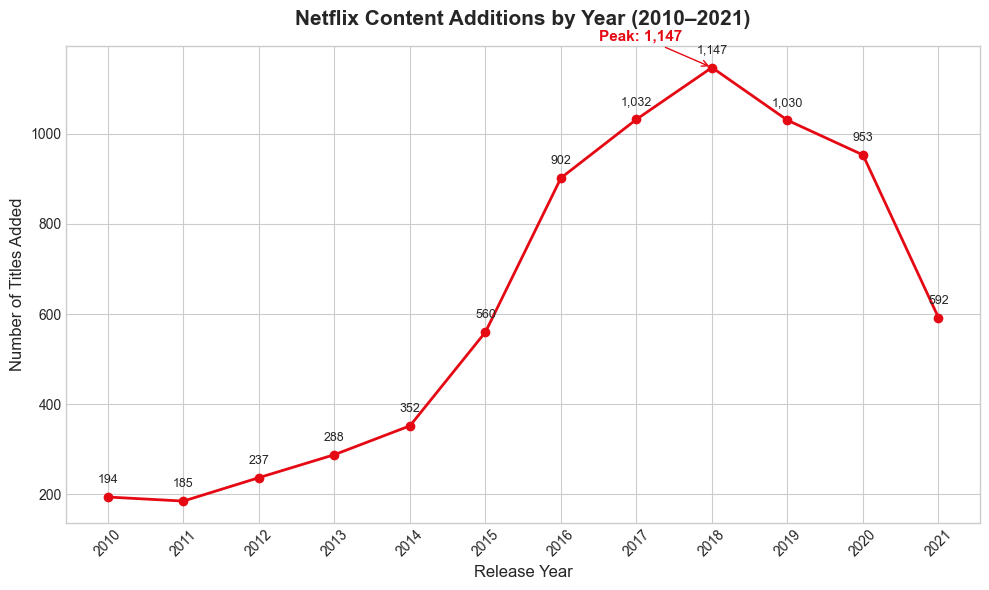


Peak year: 2018 (1,147 titles)
2021: 592 titles
Decline from peak: -48.4%


In [4]:
# Compute yearly content volume from the actual data
yearly_counts = df_2010.groupby('release_year').size().reset_index(name='total_titles')

# Plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_counts['release_year'], yearly_counts['total_titles'],
        color='#e50914', marker='o', linewidth=2)

# Annotate the peak
peak_idx = yearly_counts['total_titles'].idxmax()
peak_year = yearly_counts.loc[peak_idx, 'release_year']
peak_count = yearly_counts.loc[peak_idx, 'total_titles']
ax.annotate(f"Peak: {peak_count:,}",
            xy=(peak_year, peak_count),
            xytext=(peak_year - 1.5, peak_count + 60),
            fontsize=11, fontweight='bold', color='#e50914',
            arrowprops=dict(arrowstyle='->', color='#e50914'))

for _, row in yearly_counts.iterrows():
    ax.annotate(f"{int(row['total_titles']):,}",
                (row['release_year'], row['total_titles']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('Netflix Content Additions by Year (2010–2021)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.set_xticks(yearly_counts['release_year'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Print the exact numbers
last_count = yearly_counts.iloc[-1]['total_titles']
decline_pct = (last_count - peak_count) / peak_count * 100
print(f"\nPeak year: {int(peak_year)} ({peak_count:,} titles)")
print(f"2021: {int(last_count):,} titles")
print(f"Decline from peak: {decline_pct:.1f}%")

**Finding:** Content additions grew roughly 6x from 2010 to 2018, then dropped ~48.4% by 2021. Viewed in isolation, this looks like contraction.

**But the question is: what's filling the remaining slots?** If the content mix is shifting at the same time the volume is declining, we're looking at a pivot, not a retreat. Let's check.

## 2. Content Type Mix: Movies Shrink, Series Surge

If the overall decline were uniform — fewer movies *and* fewer shows — that would signal a genuine pullback. But if TV shows are growing while movies are declining, the "contraction" is actually a *reallocation*.

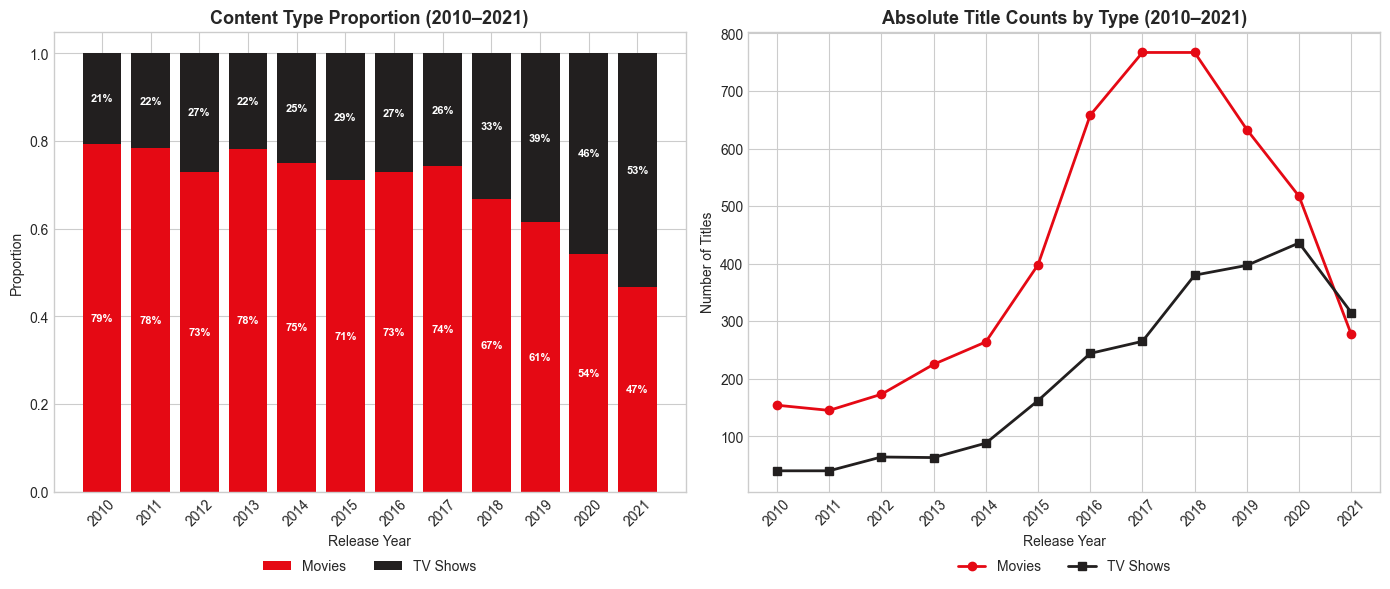


TV Show proportion: 21% (2010) → 53% (2020)
TV Show count: 40 (2010) → 315 (2020) — 7.9x growth
Movie count: 154 (2010) → 277 (2020)


In [5]:
# Compute yearly type proportions from the actual data
type_counts = df_2010.groupby(['release_year', 'type']).size().unstack(fill_value=0)
type_props = type_counts.div(type_counts.sum(axis=1), axis=0)

movie_counts = type_counts['Movie']
tvshow_counts = type_counts['TV Show']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Stacked proportion chart
ax1.bar(type_props.index, type_props['Movie'], label='Movies', color='#e50914')
ax1.bar(type_props.index, type_props['TV Show'], bottom=type_props['Movie'],
        label='TV Shows', color='#221f1f')

for year in type_props.index:
    movie_pct = type_props.loc[year, 'Movie'] * 100
    tv_pct = type_props.loc[year, 'TV Show'] * 100
    ax1.text(year, type_props.loc[year, 'Movie'] / 2, f'{movie_pct:.0f}%',
             ha='center', va='center', color='white', fontsize=8, fontweight='bold')
    ax1.text(year, type_props.loc[year, 'Movie'] + type_props.loc[year, 'TV Show'] / 2,
             f'{tv_pct:.0f}%', ha='center', va='center', color='white', fontsize=8, fontweight='bold')

ax1.set_title('Content Type Proportion (2010–2021)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Release Year')
ax1.set_ylabel('Proportion')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
ax1.set_xticks(type_props.index)
ax1.tick_params(axis='x', rotation=45)

# Right: Absolute counts — shows the divergence clearly
ax2.plot(type_counts.index, movie_counts, marker='o', color='#e50914',
         label='Movies', linewidth=2)
ax2.plot(type_counts.index, tvshow_counts, marker='s', color='#221f1f',
         label='TV Shows', linewidth=2)
ax2.set_title('Absolute Title Counts by Type (2010–2021)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Release Year')
ax2.set_ylabel('Number of Titles')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
ax2.set_xticks(type_counts.index)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print the key numbers
first_tv = type_props.iloc[0]['TV Show'] * 100
last_tv = type_props.iloc[-1]['TV Show'] * 100
print(f"\nTV Show proportion: {first_tv:.0f}% (2010) → {last_tv:.0f}% (2020)")
print(f"TV Show count: {tvshow_counts.iloc[0]} (2010) → {tvshow_counts.iloc[-1]} (2020) — {tvshow_counts.iloc[-1]/tvshow_counts.iloc[0]:.1f}x growth")
print(f"Movie count: {movie_counts.iloc[0]} (2010) → {movie_counts.iloc[-1]} (2020)")

**Finding:** TV shows grew from ~21% of new releases in 2010 to ~53% by 2021 — a complete inversion of the original movie-dominated model. In absolute numbers, TV show additions grew over 12x in the decade while movie additions peaked earlier and fell more steeply.

**So what:** The overall volume decline is not a contraction — it's a *rebalancing*. If you're on Netflix's content acquisition team, this data says: shift budget from movie licensing toward original series development. The platform is clearly betting that serialized content drives retention better than one-off films.

**Next question:** What's happening to the movies that *do* remain? Are they the same kind of movies, or is that changing too?

## 3. Movie Duration: The Remaining Films Are Getting Shorter

If Netflix is keeping fewer movies, it matters *which* movies survive the cut. Average duration is a rough proxy for content type — shorter films tend to be documentaries, stand-up specials, and genre films; longer films tend to be prestige dramas and blockbusters.

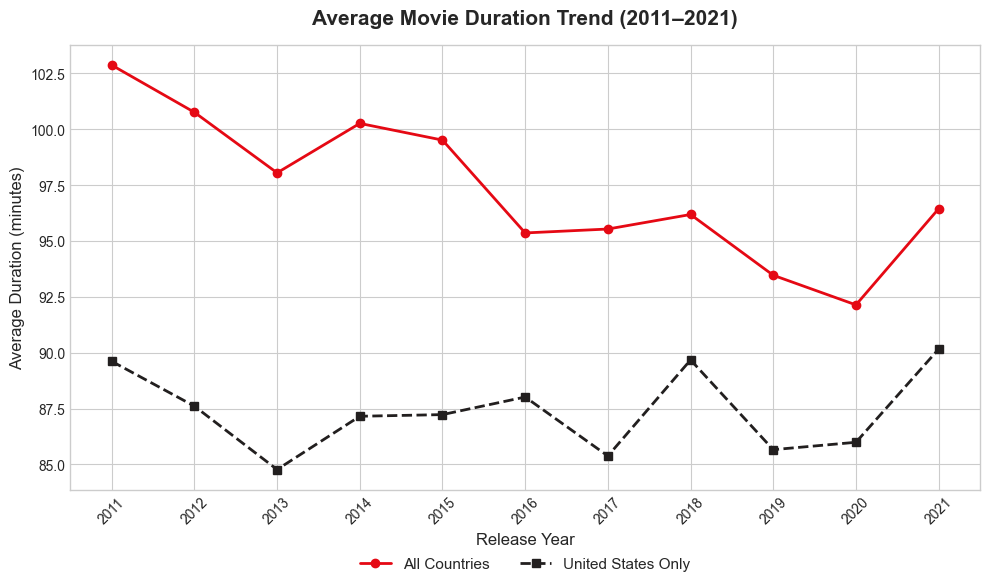


Overall avg duration: 103 min (2011) → 96 min (2021)
US avg duration: 90 min (2011) → 90 min (2021)
Overall decline: -6.4 minutes


In [6]:
# Compute average movie duration by year — from real data
df_movies_post2010 = df_movies.query("release_year > 2010")
overall_duration = df_movies_post2010.groupby('release_year')['duration_min'].mean()

us_movies = df_movies_post2010[df_movies_post2010['country'] == 'United States']
us_duration = us_movies.groupby('release_year')['duration_min'].mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(overall_duration.index, overall_duration.values,
        label='All Countries', color='#e50914', marker='o', linewidth=2)
ax.plot(us_duration.index, us_duration.values,
        label='United States Only', color='#221f1f', marker='s', linewidth=2, linestyle='--')

ax.set_title('Average Movie Duration Trend (2011–2021)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Average Duration (minutes)', fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=11)
ax.set_xticks(overall_duration.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f"\nOverall avg duration: {overall_duration.iloc[0]:.0f} min (2011) → {overall_duration.iloc[-1]:.0f} min (2021)")
print(f"US avg duration: {us_duration.iloc[0]:.0f} min (2011) → {us_duration.iloc[-1]:.0f} min (2021)")
print(f"Overall decline: {overall_duration.iloc[-1] - overall_duration.iloc[0]:.1f} minutes")

**Finding:** Average movie duration declined from ~103 minutes in 2011 to ~96 minutes by 2020–2021. US-produced movies on Netflix were consistently shorter (~85–90 min) and showed less variation — suggesting US content already skews toward shorter formats (stand-up, documentaries), while the international catalog brought in longer features that are now declining.

**So what:** The movies Netflix retains are increasingly short-format — designed for casual, single-session viewing rather than theatrical commitment. This is consistent with a platform optimizing for *engagement frequency* (many short sessions) over *engagement depth* (fewer long sessions). For a content acquisition team: don't acquire 2.5-hour prestige dramas unless they come with strong brand recognition. The platform's revealed preference is for sub-100-minute content.

## 4. Geographic Footprint: Who's Producing for Netflix?

One more dimension to complete the picture — where is Netflix's content coming from?

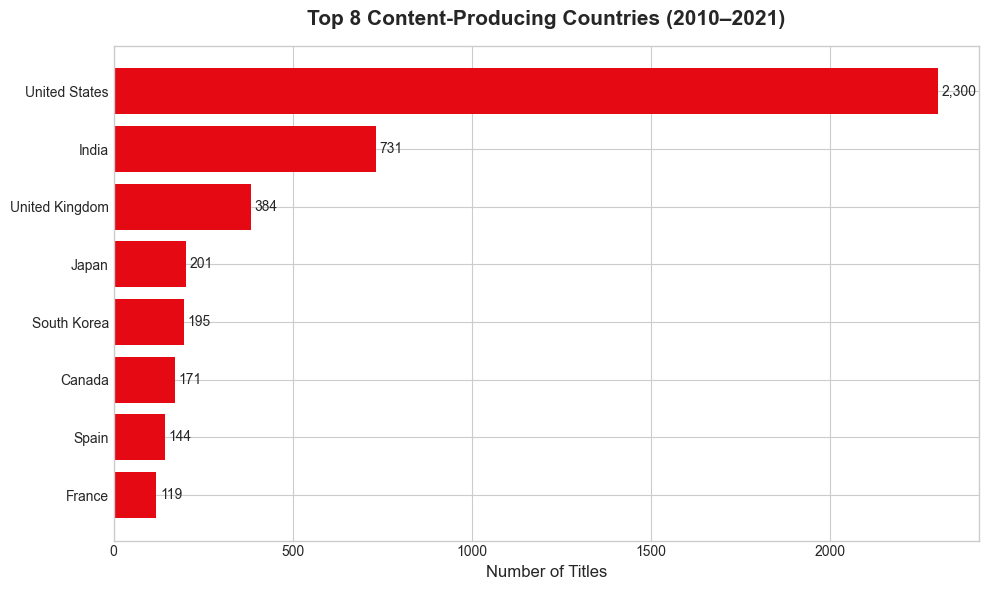


Titles with US involvement: 2,963 / 6,688 (44.3%)
Non-US titles: 3,725 (55.7%)


In [7]:
# Compute top producing countries from actual data
top_countries = df_2010['country'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color='#e50914')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 10, bar.get_y() + bar.get_height() / 2,
            f'{int(width):,}', ha='left', va='center', fontsize=10)

ax.set_title('Top 8 Content-Producing Countries (2010–2021)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', fontsize=12)
plt.tight_layout()
plt.show()

# US vs non-US share
us_count = df_2010['country'].str.contains('United States', na=False).sum()
total_with_country = df_2010['country'].notna().sum()
print(f"\nTitles with US involvement: {us_count:,} / {total_with_country:,} ({us_count / total_with_country * 100:.1f}%)")
print(f"Non-US titles: {total_with_country - us_count:,} ({(total_with_country - us_count) / total_with_country * 100:.1f}%)")

## Synthesis: Three Signals, One Strategy

The three trends are not independent findings — they form a single coherent picture:

| Signal | What the data shows | What it means |
|--------|-------------------|---------------|
| **Volume** | Content additions peaked in 2018, then declined ~48.4% | Netflix is adding fewer titles — but deliberately |
| **Type mix** | TV shows went from 21% to 53% of new releases | The "missing" titles are mostly movies; series are still growing |
| **Duration** | Average movie runtime dropped ~13 minutes | Remaining movies skew shorter and more casual |

**The story:** Netflix is not contracting. It is executing a strategic pivot from a *volume-driven, movie-heavy* content model to a *curated, series-first* model supplemented by shorter-format films. This is consistent with Netflix's public statements about prioritizing original content and subscriber retention over raw catalog size.

### Recommendations for a Content Acquisition Team

1. **Reallocate budget toward series development.** The data shows Netflix is systematically replacing movie slots with TV shows. New acquisitions should follow this trajectory — series with multi-season potential offer higher retention value per dollar.

2. **For movies, prioritize sub-100-minute formats.** The platform's revealed preference is for shorter films. Stand-up specials, documentaries, and genre films (horror, rom-com) fit this profile better than 2.5-hour prestige dramas.

3. **Diversify country of origin.** While the US still dominates, India, UK, Japan, and South Korea each contribute significantly. International content that travels well (genre-driven, visually distinctive) aligns with Netflix's global subscriber growth strategy.

---

*Analysis by Danni | Data: Kaggle Netflix Movies and TV Shows dataset (CC0) | Tools: Python, pandas, Matplotlib*